In [22]:
#判別システム全体
#前処理フェーズ，判別フェーズ

#前処理フェーズ：YOLO
#入力：画像フォルダ
#出力：前処理後の画像

#判別フェーズ
#入力：画像フォルダ
#出力：判別結果

In [23]:
import os 
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import scipy.stats as stats
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_curve
import re
import math
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,precision_score, recall_score, f1_score
import joblib
import time
from ultralytics import YOLO

In [24]:
import os
import cv2
import numpy as np
from ultralytics import YOLO

# 入力と出力
input_folder = "/home/data/jikuari_maesyori_gakusyu/hukusugazou_aabbcc"
base_output_path = "/home/data/jikuari_maesyori_gakusyu"
crop_output_base = os.path.join(base_output_path, "crop")  # crop フォルダ
mask_output_base = os.path.join(base_output_path, "mask")  # mask フォルダ
combined_output_base = os.path.join(base_output_path, "combined")  # combined フォルダ

# モデルの読み込み
detection_model = YOLO('/home/YOLO/hukusuu_train/datasets/train7/weights/best.pt')
segmentation_model = YOLO("/home/YOLO/-327_seg/datasets/train2/weights/best.pt")

from string import ascii_uppercase
labels = list(ascii_uppercase)

# 通し番号（すべての画像で一意）
global_counter = 1

def process_image(image_path, collage_index):
    global global_counter

    results = detection_model.predict(image_path)
    orig_img = results[0].orig_img
    img_h, img_w, _ = orig_img.shape

    rows, cols = 4, 6
    cell_h, cell_w = img_h // rows, img_w // cols

    cell_bboxes = [[[] for _ in range(cols)] for _ in range(rows)]

    if results[0].boxes is not None:
        for box in results[0].boxes.xyxy:
            start_x, start_y, end_x, end_y = map(int, box)
            center_x = (start_x + end_x) // 2
            center_y = (start_y + end_y) // 2
            row_idx = min(center_y // cell_h, rows - 1)
            col_idx = min(center_x // cell_w, cols - 1)
            cell_bboxes[row_idx][col_idx].append((start_x, start_y, end_x, end_y))

    for r in range(rows):
        for c in range(cols):
            grade = c // 2
            grade_label = labels[grade]
            crop_folder = os.path.join(crop_output_base, grade_label)  # crop フォルダ
            mask_folder = os.path.join(mask_output_base, grade_label)  # mask フォルダ
            combined_folder = os.path.join(combined_output_base, grade_label)  # combined フォルダ

            os.makedirs(crop_folder, exist_ok=True)
            os.makedirs(mask_folder, exist_ok=True)
            os.makedirs(combined_folder, exist_ok=True)

            if not cell_bboxes[r][c]:
                continue

            for (sx, sy, ex, ey) in cell_bboxes[r][c]:
                clip_img = orig_img[sy:ey, sx:ex]

                # ファイル名生成
                filename = f"crop_{collage_index}_{global_counter}.jpg"  # crop のファイル名
                global_counter += 1

                # cropフォルダに保存
                cv2.imwrite(os.path.join(crop_folder, filename), clip_img)

                # セグメンテーション
                mask_results = segmentation_model.predict(clip_img)
                if mask_results and mask_results[0].masks is not None:
                    mask = mask_results[0].masks.data[0].cpu().numpy()
                    mask = (mask * 255).astype(np.uint8)
                    mask_resized = cv2.resize(mask, (clip_img.shape[1], clip_img.shape[0]))

                    # maskフォルダに保存 (ファイル名変更)
                    mask_filename = f"mask_{collage_index}_{global_counter}.jpg"  # 変更: 'mask' プレフィックス
                    cv2.imwrite(os.path.join(mask_folder, mask_filename), mask_resized)

                    mask_rgb = cv2.cvtColor(mask_resized, cv2.COLOR_GRAY2BGR)
                    combined_img = cv2.bitwise_and(clip_img, mask_rgb)

                    # combinedフォルダに保存
                    combined_filename = f"combined_{collage_index}_{global_counter}.jpg"  # combined のファイル名
                    cv2.imwrite(os.path.join(combined_folder, combined_filename), combined_img)

# 全画像を処理
image_files = sorted(f for f in os.listdir(input_folder) if f.lower().endswith(('jpg', 'jpeg', 'png')))
for image_name in image_files:
    image_path = os.path.join(input_folder, image_name)

    # collage_1.jpg → 1 に変換
    collage_index = os.path.splitext(image_name)[0].split("_")[-1]
    if collage_index.isdigit():
        collage_index = int(collage_index)
    else:
        continue  # 整数でない場合スキップ

    print(f"Processing: {image_name}")
    process_image(image_path, collage_index)


Processing: collage_1.jpg

image 1/1 /home/data/jikuari_maesyori_gakusyu/hukusugazou_aabbcc/collage_1.jpg: 320x640 25 shiitake_bboxs, 29.5ms
Speed: 1.6ms preprocess, 29.5ms inference, 0.6ms postprocess per image at shape (1, 3, 320, 640)

0: 640x512 1 shiitake, 26.2ms
Speed: 0.9ms preprocess, 26.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 512)

0: 448x640 1 shiitake, 24.4ms
Speed: 0.9ms preprocess, 24.4ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)

0: 640x640 1 shiitake, 20.7ms
Speed: 0.8ms preprocess, 20.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x576 1 shiitake, 30.1ms
Speed: 1.1ms preprocess, 30.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 576)

0: 640x640 1 shiitake, 20.4ms
Speed: 1.1ms preprocess, 20.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 shiitake, 20.1ms
Speed: 1.1ms preprocess, 20.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640,

In [ ]:
import hida
import keijo
import size_module
#判別フェーズ
#特徴量抽出
data = "jikuari_maesyori_gakusyu"
hida_tappleA = hida.Hida_folder_jikuari(base_dir=f"/home/data/{data}",subfolder="A",method="45rotate",n=9,T=0.4)
result_hidaA = hida_tappleA.run_all()
hida_tappleB = hida.Hida_folder_jikuari(base_dir=f"/home/data/{data}",subfolder="B",method="45rotate",n=9,T=0.4)
result_hidaB = hida_tappleB.run_all()
hida_tappleC = hida.Hida_folder_jikuari(base_dir=f"/home/data/{data}",subfolder="C",method="45rotate",n=9,T=0.4)
result_hidaC = hida_tappleC.run_all()

In [ ]:
# import hida
# import keijo
# import size_module
# #判別フェーズ軸なし
# #特徴量抽出
# data = "jikuari_maesyori_gakusyu"
# hida_tappleA = hida.Hida_folder(base_dir=f"/home/data/{data}",subfolder="A",n=9,T=0.4)
# result_hidaA = hida_tappleA.run_all()
# hida_tappleB = hida.Hida_folder(base_dir=f"/home/data/{data}",subfolder="B",n=9,T=0.4)
# result_hidaB = hida_tappleB.run_all()
# hida_tappleC = hida.Hida_folder(base_dir=f"/home/data/{data}",subfolder="C",n=9,T=0.4)
# result_hidaC = hida_tappleC.run_all()

/usr/local/lib/python3.11/site-packages/hida/__main__.py:147: RuntimeWarning: invalid value encountered in scalar divide
  return Tr / Tm
/usr/local/lib/python3.11/site-packages/hida/__main__.py:147: RuntimeWarning: divide by zero encountered in scalar divide
  return Tr / Tm


In [27]:
dfA = pd.DataFrame(result_hidaA, columns=["filename", "R"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "R"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "R"])
dfA ["Label"] = "0"
dfB ["Label"] = "1"
dfC ["Label"] = "2"
result_hida = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)

In [28]:
size_tappleA = size_module.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="A")
result_sizeA = size_tappleA.run()
size_tappleB = size_module.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="B")
result_sizeB = size_tappleB.run()
size_tappleC = size_module.Size_folder_taikakusen(base_dir=f"/home/data/{data}",subfolder="C")
result_sizeC = size_tappleC.run()

探索対象フォルダ: /home/data/jikuari_maesyori_gakusyu/mask/A
探索対象フォルダ: /home/data/jikuari_maesyori_gakusyu/mask/B
探索対象フォルダ: /home/data/jikuari_maesyori_gakusyu/mask/C


In [29]:
# size_tappleA = size_module.Size_folder(base_dir=f"/home/data/{data}",subfolder="A")
# result_sizeA = size_tappleA.run()
# size_tappleB = size_module.Size_folder(base_dir=f"/home/data/{data}",subfolder="B")
# result_sizeB = size_tappleB.run()
# size_tappleC = size_module.Size_folder(base_dir=f"/home/data/{data}",subfolder="C")
# result_sizeC = size_tappleC.run()

In [30]:
dfA = pd.DataFrame(result_sizeA, columns=["filename", "size_count"])                                                    
dfB = pd.DataFrame(result_sizeB, columns=["filename", "size_count"])
dfC = pd.DataFrame(result_sizeC, columns=["filename", "size_count"])
result_size = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)

In [31]:
keijo_tappleA = keijo.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="A")
result_keijoA = keijo_tappleA.run()
keijo_tappleB = keijo.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="B")
result_keijoB = keijo_tappleB.run()
keijo_tappleC = keijo.Keijo_folder(base_dir=f"/home/data/{data}",subfolder="C")
result_keijoC = keijo_tappleC.run()


📂 フォルダ: /home/data/jikuari_maesyori_gakusyu/mask/A に画像 42 枚
📂 フォルダ: /home/data/jikuari_maesyori_gakusyu/mask/B に画像 40 枚
📂 フォルダ: /home/data/jikuari_maesyori_gakusyu/mask/C に画像 40 枚


In [32]:
dfA = pd.DataFrame(result_hidaA, columns=["filename", "MSE"])
dfB = pd.DataFrame(result_hidaB, columns=["filename", "MSE"])
dfC = pd.DataFrame(result_hidaC, columns=["filename", "MSE"])
result_keijo = pd.concat([dfA, dfB, dfC], axis=0,ignore_index=True)

In [33]:
df_merged = pd.merge(result_keijo, result_size, on="filename")
df_merged = pd.merge(df_merged, result_hida, on="filename")
df_merged.to_csv(f"/home/data/{data}/feature.csv", index=False)

Train Data Class Distribution:
Label
0    29
1    28
2    28
Name: count, dtype: int64

Test Data Class Distribution:
Label
0    13
1    12
2    12
Name: count, dtype: int64
              precision  recall  f1-score  support
0                0.6875  0.8462    0.7586  13.0000
1                0.8889  0.6667    0.7619  12.0000
2                0.5833  0.5833    0.5833  12.0000
accuracy         0.7027  0.7027    0.7027   0.7027
macro avg        0.7199  0.6987    0.7013  37.0000
weighted avg     0.7190  0.7027    0.7028  37.0000


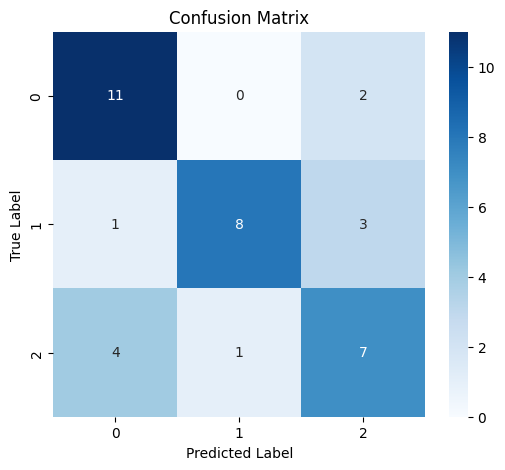

In [ ]:
#SVM

model =" _test"

# === 1. データの読み込み ===
merged_data_csv = f"/home/data/{data}/feature.csv"
df = pd.read_csv(merged_data_csv)
# === 2. 特徴量とターゲット変数の定義 ===
X = df[["MSE", "size_count", "R"]]  # 特徴量
y = df["Label"]  # 目的変数

# === 3. 訓練データとテストデータに分割 ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# 訓練データとテストデータのクラスごとのカウント
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# 結果を表示
print("Train Data Class Distribution:")
print(train_counts)
print("\nTest Data Class Distribution:")
print(test_counts)


# === 4. 特徴量の標準化 ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# === 5. SVMの学習 (RBFカーネル) ===
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr')
svm_model.fit(X_train, y_train)


# 学習済みモデルを保存
model_path = f"svm_model{model}.pkl"
joblib.dump(svm_model, model_path)

# 標準化のスケーラーも保存
scaler_path = f"scaler{model}.pkl"
joblib.dump(scaler, scaler_path)


# === 6. 予測と評価 ===
y_pred = svm_model.predict(X_test)

# レポートを辞書形式で取得
report_dict = classification_report(y_test, y_pred, output_dict=True)

# DataFrameに変換
report_df = pd.DataFrame(report_dict).transpose()

# 表示（必要に応じて四捨五入）
print(report_df.round(4))

# y_testが持つインデックスを使い、元のdfからテストデータに該当する行だけを抽出
test_data_with_results = df.loc[y_test.index].copy()

# 抽出したテストデータに、予測結果の列を追加
# これで左辺(test_data_with_results)と右辺(y_pred)の行数が一致する
test_data_with_results['Predicted_Label'] = y_pred

# 結果を新しいCSVファイルとして保存
output_path = f"/home/data/{data}/BBBpredicted_results{model}.csv"
test_data_with_results.to_csv(output_path, index=False)


# === 7. 混同行列の可視化 ===
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [35]:
# #予測
# # === モデルとスケーラーの読み込み ===
# model_path = f"svm_model{model}.pkl"
# scaler_path = f"scaler{model}.pkl"

# svm_model = joblib.load(model_path)
# scaler = joblib.load(scaler_path)

# # === 新しいデータの読み込み ===
# # df = pd.DataFrame(merged)
# df = pd.read_csv(f'/home/data/{data}/feature.csv')
# df = pd.DataFrame(df)

# # === 特徴量の抽出と標準化 ===
# X_new = df[["MSE", "size_count", "R"]]  # 学習時と同じ特徴量を使用
# X_new = scaler.transform(X_new)  # 標準化

# # === 予測 ===
# y_pred_new = svm_model.predict(X_new)

# # 結果をDataFrameに追加
# df["Predicted_Label"] = y_pred_new

# # 予測結果の確認
# print([["MSE", "size_count", "R", "Predicted_Label"]])

# # CSVとして保存（オプション）
# df.to_csv(f"/home/data/{data}/predicted_results.csv", index=False)

# # 精度の表示
# accuracy = accuracy_score(df["Label"], df["Predicted_Label"])
# precision = precision_score(df["Label"], df["Predicted_Label"], average='macro')
# recall = recall_score(df["Label"], df["Predicted_Label"], average='macro')
# f1 = f1_score(df["Label"], df["Predicted_Label"], average='macro')
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1: {f1:.4f}")
# # 混同行列の可視化
# cm = confusion_matrix(df["Label"], df["Predicted_Label"])
# plt.figure(figsize=(6, 5))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()

In [36]:
# df  = pd.read_csv("/home/data/jikuari_maesyori_gakusyu/predicted_results.csv")
# df = pd.DataFrame(df)
# # 正解ラベルと予測ラベル
# y_true = df["Label"]
# y_pred = df["Predicted_Label"]

# # 精度 (accuracy)
# accuracy = accuracy_score(y_true, y_pred)
# print("Accuracy:", accuracy)

# # 詳細レポート
# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, digits=4))


In [37]:
# import hida
# a = hida.Hida_file_jikuari(
#                             img_path = "/home/data/jikuari_maesyori_gakusyu/combined/B/combined_1_18.jpg",
#                            mask_path = "/home/data/jikuari_maesyori_gakusyu/mask/B/mask_1_18.jpg", 
#                            method="45rotate")
# result = a.main()
# print(result)

In [38]:
# import hida
# a = hida.Hida_folder(base_dir="/home/data/maesyori_img")
# result = a.run_all()
# print(result)

In [39]:
# import size

# a = size.Size_file("/home/data/maesyori_img/mask/collage_1/mask_1_1.jpg")
# result = a.count_white_pixels()
# print(result)

In [40]:
# import size_module
# import os
# import cv2
# import numpy as np
# b = size_module.Size_folder(base_dir="/home/data/maesyori_img")
# result = b.count_white_pixels()
# print(result)

In [41]:
# import keijo
# analyzer = keijo.Keijo_file("/home/data/maesyori_img/mask/collage_1/mask_1_1.jpg")
# result = analyzer.run()
# print(result)

In [42]:
# import keijo
# analyzer = keijo.Keijo_folder(base_dir="/home/data/maesyori_img")
# result = analyzer.run()
# print(result)